In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import numpy as np
import SRW_v044_ctMC as SRW
from scipy.sparse import csr_matrix, csc_matrix, issparse
import functools
from base_network import make_network

In [5]:
nsamples = 100
nnodes = 1000
edge_freq = 0.004
cliq_edge_freq = 0.114
hi_mut_freq = 0.5
hi_node = nnodes*3/4
group_labels = ['Subtype 1']*(nsamples//2) + ['Subtype 2']*(nsamples//2)
feature_names = ['Subnetwork 1', 'Subnetwork 2', 'High mut source', 'High mut target', 
                 'Random 1', 'Random 2', 
                 'Self loop', 'Intercept']
node_names = ['{}'.format(i) for i in range(1,nnodes+1)]
sample_names = ['{}'.format(i) for i in range(1,nsamples+1)]

rand_mut_freq = 0.015

In [6]:
rst_prob = 0.3
lam = 1e-1
WMW_b = 2e-4

In [7]:
network_type = 'cliq_random' # 'random', 'scale_free', 'small_world', 'cliq_random'
edges, features = make_network(network_type, nnodes, edge_freq, cliq_edge_freq)

P_init = []
for p in range(nsamples):
    p_init = []
    for i in range(nnodes):
        freq=0
        if p == i:
            freq = 1
        elif i == hi_node:
            freq = hi_mut_freq
        elif i<100:
            if (max(p,i)<50 or min(p,i)>=50):
                freq = 0.015
            else:
                freq = 0.000
        else:
            freq = rand_mut_freq

        if np.random.random() < freq:
            p_init.append(1)
        else:
            p_init.append(0)

    P_init.append(p_init)
P_init = csr_matrix(P_init)

SRW_obj = SRW.SRW_solver(edges, features, nnodes, P_init, rst_prob, group_labels, lam, w_init_sd=0.01, 
                         w=None, feature_names=feature_names, sample_names=sample_names, 
                         node_names=node_names, loss='WMW', norm_type='L1', learning_rate=0.5, 
                         update_w_func='Adam', P_init_val=P_init, group_labels_val=group_labels, 
                         ncpus=len(feature_names), maxit=1000, early_stop=10, WMW_b=WMW_b)
SRW_obj.train_SRW_GD()

finished calculating strength_grad: 01:27:23
finished network propagation: 01:27:23
finished calculating P_grad using pool: 01:27:24
finished calculating J and J_grad: 01:27:26
*** 0 iteration: J is 42.87811151391739 cost_val is 8.998187867087484
*** accuracy is 0.68 accuracy_val is 1.0


finished calculating strength_grad: 01:27:27
finished network propagation: 01:27:29
finished calculating P_grad using pool: 01:27:31
finished calculating J and J_grad: 01:27:31
*** 1 iteration: J is 42.77679504405931 cost_val is 8.547026500399154
*** accuracy is 0.68 accuracy_val is 1.0


finished calculating strength_grad: 01:27:34
finished network propagation: 01:27:36
finished calculating P_grad using pool: 01:27:37
finished calculating J and J_grad: 01:27:37
*** 2 iteration: J is 42.27951991361209 cost_val is 8.448377512808277
*** accuracy is 0.68 accuracy_val is 1.0


finished calculating strength_grad: 01:27:39
finished network propagation: 01:27:40
finished calculating P_grad using pool: 01:27:

In [8]:
SRW_obj.w_map

,Weight
Subnetwork 1,8.834341
Subnetwork 2,8.403495
High mut source,-0.141328
High mut target,0.027394
Random 1,-3.905681
Random 2,-3.276655
Self loop,-1.982052
Intercept,-10.347126


In [9]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
SRW_obj.w = SRW_obj.w_list[0]
SRW_obj.map_w()
SRW_obj.w[-1] = 100
SRW_obj.w[-2] = -200
SRW_obj.Q = SRW.generate_Q(SRW_obj.edges, SRW_obj.nnodes, SRW_obj.features, SRW_obj.w)
P = SRW.iterative_PPR(SRW_obj.Q.toarray(), SRW.renorm(SRW_obj.P_init).toarray(), SRW_obj.rst_prob)
SRW_obj.C = SRW_obj.centroid(P, SRW_obj.ngroups, SRW_obj.group2indeces_list)
SRW_obj.calc_cost_and_acc_val()
SRW_obj.generate_Q_and_P_fin()

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
P_df = SRW_obj.P_fin_df.copy()
P_df_pca = pca.fit_transform(P_df)
explained_variance_ratio = pca.explained_variance_ratio_


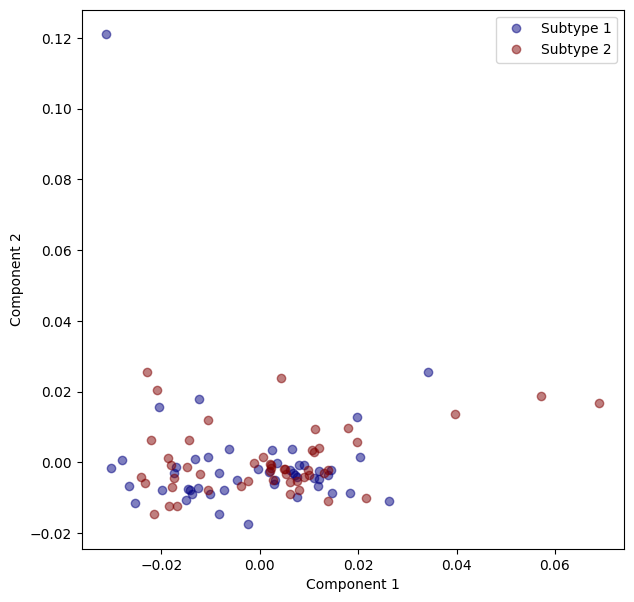

In [13]:
X = pd.DataFrame(P_df_pca, columns=['PC1', 'PC2'])
X['labels'] = group_labels

labels = X.groupby('labels')

cmap = plt.get_cmap('jet')
colors = cmap(np.linspace(0, 1.0, len(labels)))

fig, ax = plt.subplots(figsize=(7, 7))
from cycler import cycler
ax.set_prop_cycle(cycler('color', colors))

for name, label in labels:
    ax.plot(label.PC1, label.PC2, alpha=0.5, marker='o', linestyle='', label=name)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
ax.legend(loc='upper right')

plt.savefig('./sim1001000_0_PCA.pdf')
plt.show()

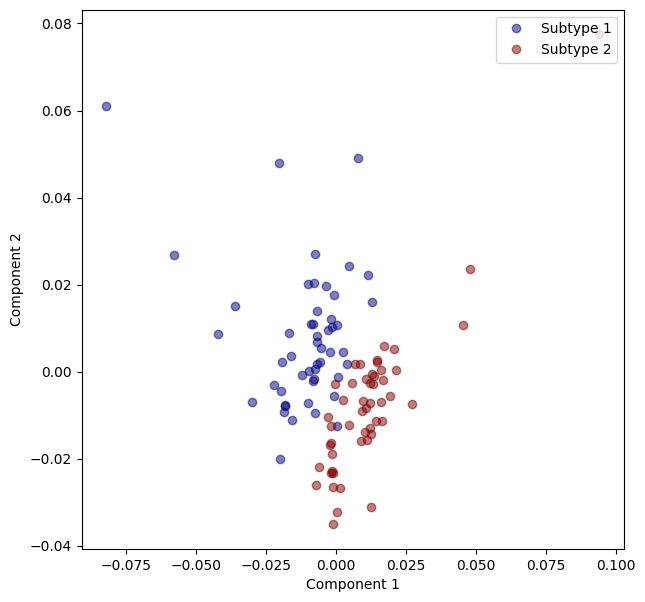

In [15]:
SRW_obj.w = SRW_obj.w_list[-1]
SRW_obj.map_w()
SRW_obj.Q = SRW.generate_Q(SRW_obj.edges, SRW_obj.nnodes, SRW_obj.features, SRW_obj.w)
P = SRW.iterative_PPR(SRW_obj.Q.toarray(), SRW.renorm(SRW_obj.P_init).toarray(), SRW_obj.rst_prob)
SRW_obj.C = SRW_obj.centroid(P, SRW_obj.ngroups, SRW_obj.group2indeces_list)
SRW_obj.calc_cost_and_acc_val()
SRW_obj.generate_Q_and_P_fin()

pca = PCA(n_components=2)
P_df = SRW_obj.P_fin_df.copy()
P_df_pca = pca.fit_transform(P_df)
explained_variance_ratio = pca.explained_variance_ratio_

X = pd.DataFrame(P_df_pca, columns=['PC1', 'PC2'])
X['labels'] = group_labels

labels = X.groupby('labels')

cmap = plt.get_cmap('jet')
colors = cmap(np.linspace(0, 1.0, len(labels)))

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_prop_cycle(cycler('color', colors))
for name, label in labels:
    ax.plot(label.PC1, label.PC2, alpha=0.5, marker='o', linestyle='', label=name)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
ax.legend(loc='upper right')

plt.savefig('./sim1001000_-1_PCA.pdf')

plt.show()

In [16]:
P_df

,1,2,3,4,5,6,7,8,9,10,...,991,992,993,994,995,996,997,998,999,1000
1,0.023585,0.008636,0.003604,0.002683,0.001042,0.002985,0.015574,0.002611,0.003071,0.000512,...,0.000533,0.000157,0.000737,0.000115,0.000097,0.000070,0.001025,0.000245,0.000879,2.009728e-06
2,0.001259,0.018824,0.004449,0.003147,0.001558,0.002852,0.001580,0.001636,0.002100,0.000655,...,0.000385,0.001004,0.000315,0.000116,0.000088,0.000213,0.001683,0.000170,0.000282,1.370729e-06
3,0.000641,0.002324,0.029288,0.000883,0.000745,0.006560,0.002417,0.001987,0.009162,0.000302,...,0.000673,0.000399,0.000024,0.000045,0.000039,0.000010,0.000129,0.000086,0.000059,8.503264e-04
4,0.000873,0.014457,0.003957,0.035724,0.001296,0.001435,0.004810,0.006745,0.002490,0.000350,...,0.000238,0.002285,0.000010,0.000086,0.000062,0.000051,0.000116,0.000200,0.000162,1.550455e-06
5,0.000875,0.010855,0.004127,0.001924,0.035628,0.002245,0.001184,0.001255,0.005920,0.000909,...,0.000685,0.000071,0.000164,0.000045,0.000023,0.000332,0.000540,0.000873,0.000032,1.357772e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.000506,0.001764,0.000678,0.000310,0.000403,0.000707,0.002448,0.000388,0.000631,0.000352,...,0.000220,0.000053,0.000015,0.002298,0.000026,0.000013,0.000091,0.001165,0.000151,9.209598e-07
97,0.000323,0.001532,0.000840,0.001283,0.000243,0.000578,0.000686,0.000490,0.000567,0.000319,...,0.008505,0.000049,0.000315,0.000083,0.000032,0.005107,0.000366,0.011393,0.000159,3.242791e-06
98,0.000264,0.001548,0.000711,0.002606,0.000204,0.001342,0.000818,0.000969,0.001061,0.000229,...,0.000343,0.000028,0.000081,0.000016,0.002051,0.000012,0.000047,0.000473,0.000361,8.726436e-07
99,0.000182,0.001218,0.000486,0.000237,0.000466,0.001724,0.000436,0.000542,0.000508,0.000215,...,0.000099,0.000077,0.000010,0.000023,0.000036,0.000116,0.000771,0.000093,0.000082,8.754084e-06


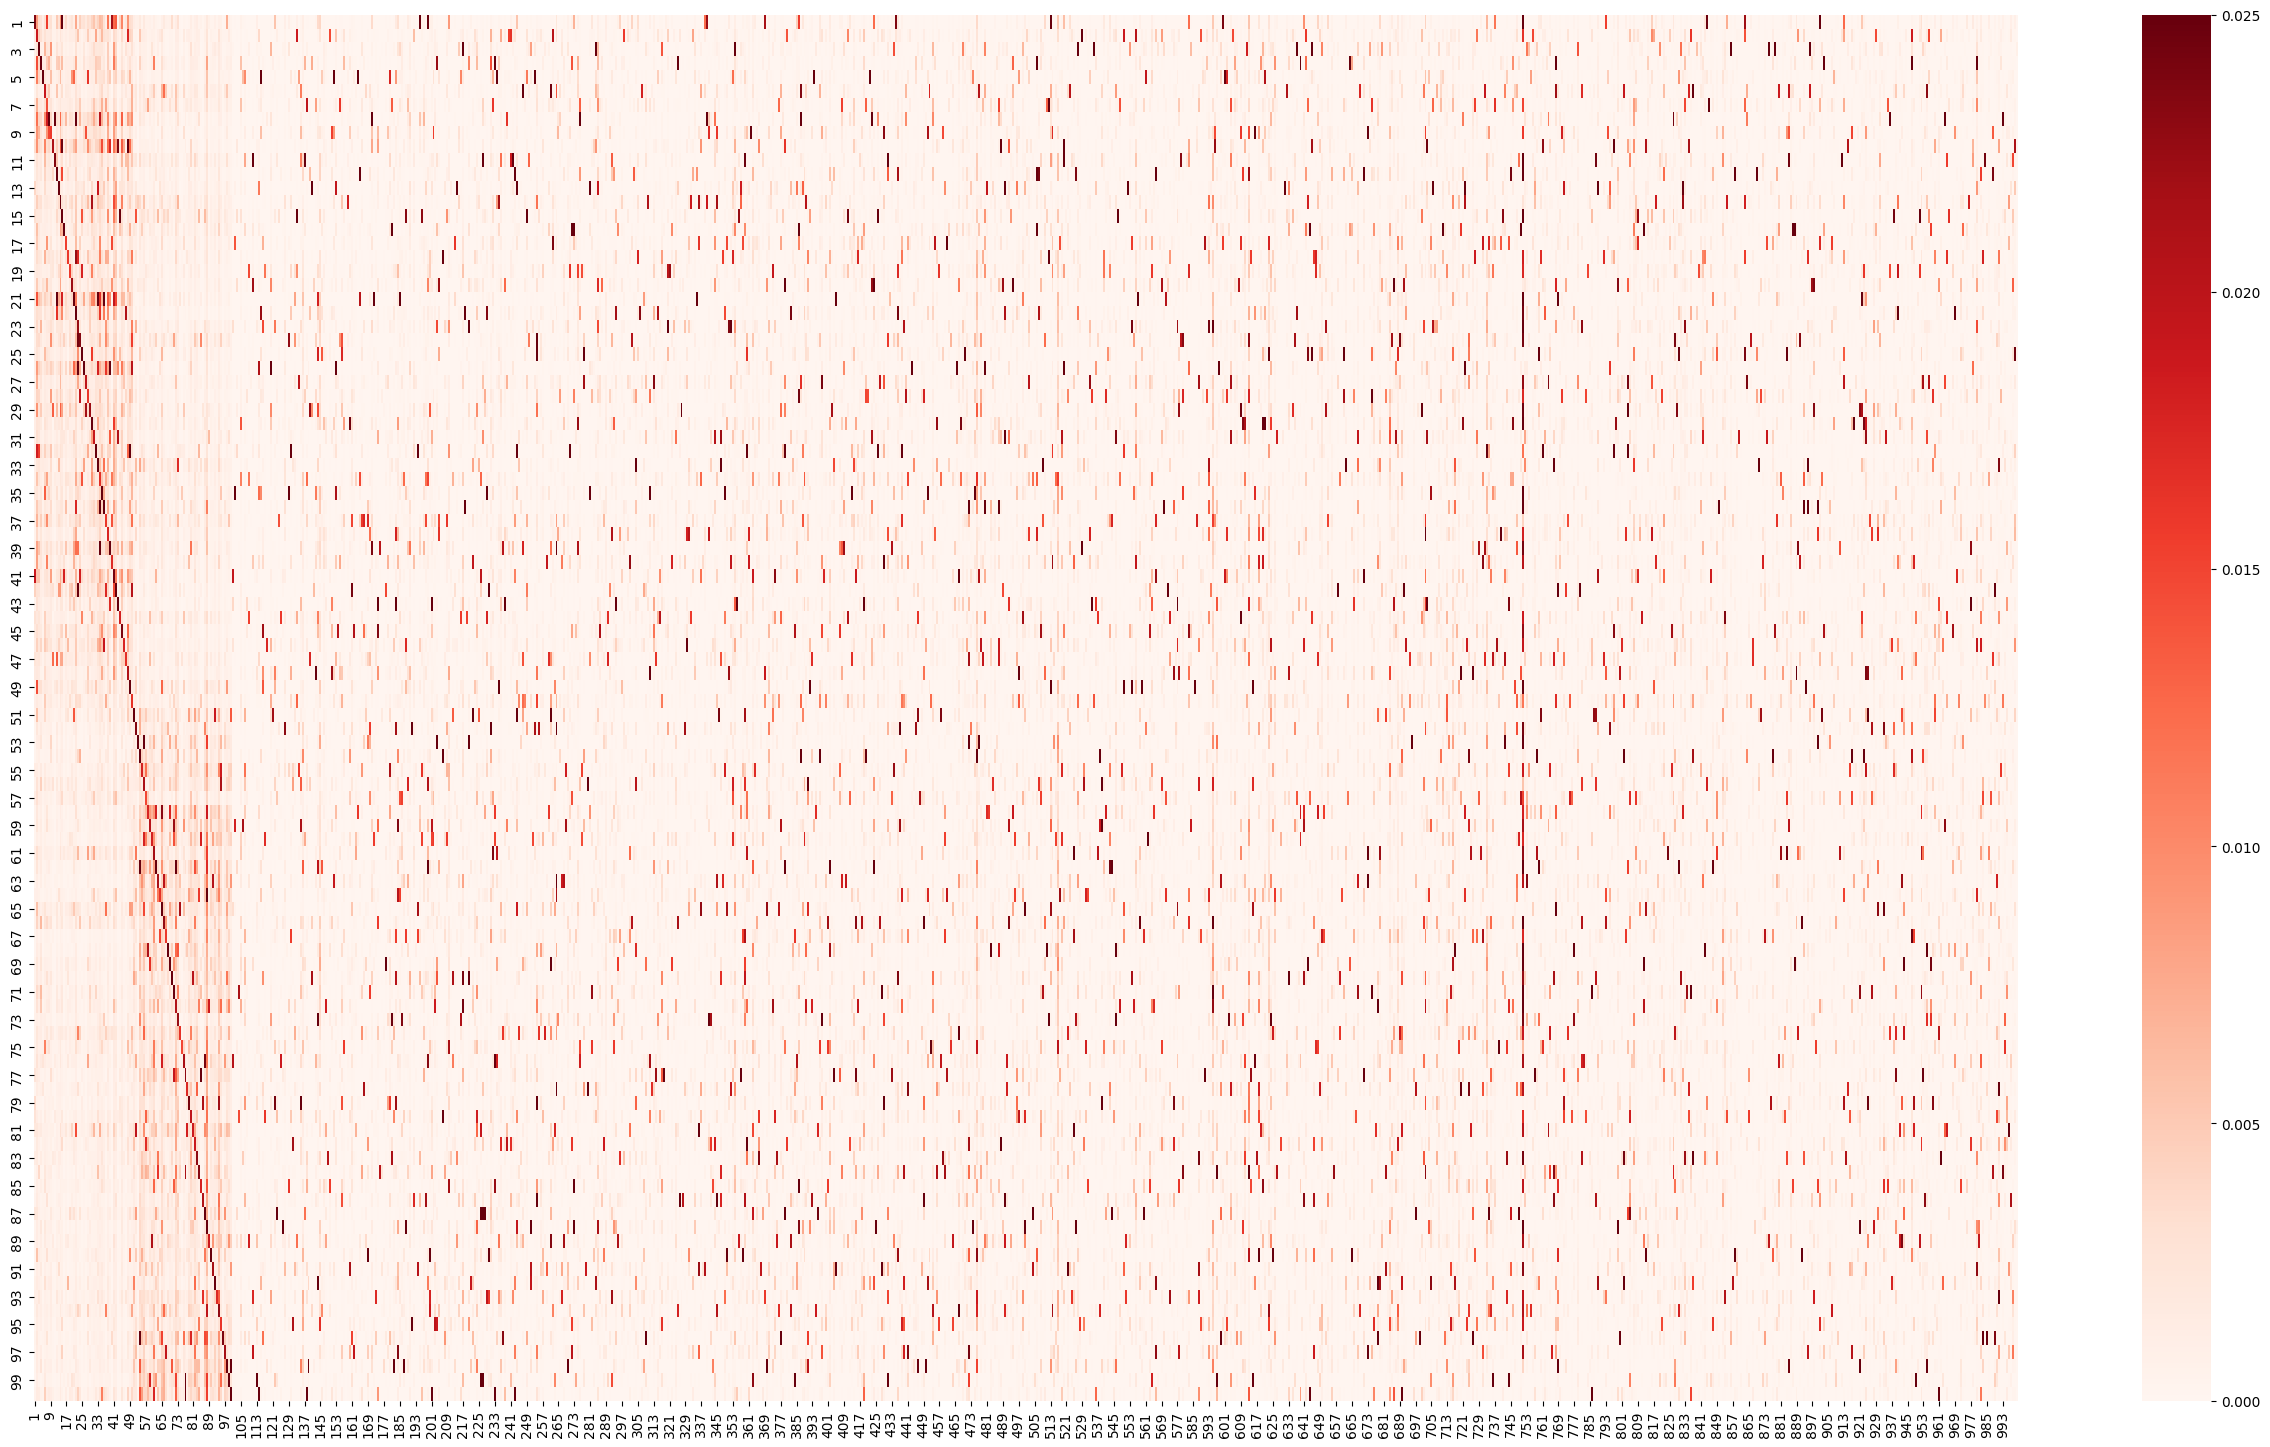

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(32,18))
ax = sns.heatmap(P_df.clip(upper=0.025),cmap='Reds', square=False)
plt.savefig('./sim1001000_P_df.pdf')